# Data Cleaning & Visualization Project

**Internship Task:** Data Cleaning & Visualization  
**Dataset:** Titanic Passenger Dataset (publicly available dataset)  

## Objective
Clean and preprocess a raw dataset, identify missing values and duplicates, examine outliers, and create visualizations to communicate useful insights.

## 1. Import Libraries

We use Pandas for data manipulation and Matplotlib/Seaborn for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load the Raw Dataset

The dataset is loaded directly from a public GitHub CSV source. If you download the CSV separately, the same analysis can be performed by replacing the URL with `titanic.csv`.

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dataset loaded successfully: {df.shape[0]} rows and {df.shape[1]} columns')
df.head()

Dataset loaded successfully: 891 rows and 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Understand the Dataset

First, inspect the structure, data types, and basic statistics.

In [3]:
print('Dataset information:')
df.info()

print('\nBasic statistics:')
display(df.describe(include='all').T)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 4. Check Missing Values

Missing values can affect analysis and machine learning models, so we identify them before processing.

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'Missing Values': missing,
    'Missing Percentage': missing_percent.round(2)
})
display(missing_summary[missing_summary['Missing Values'] > 0])

,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## 5. Handle Missing Values

For the Titanic dataset, missing values in `Age` are replaced with the median age. Missing values in `Embarked` are replaced with the most frequent category. The `Cabin` column has a very high percentage of missing values, so it is removed for this analysis.

In [5]:
clean_df = df.copy()

clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median())
clean_df['Embarked'] = clean_df['Embarked'].fillna(clean_df['Embarked'].mode()[0])
clean_df = clean_df.drop(columns=['Cabin'])

print('Missing values after cleaning:')
display(clean_df.isnull().sum())

Missing values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 6. Check and Remove Duplicates

Duplicate records can distort counts and statistical summaries.

In [6]:
duplicate_count = clean_df.duplicated().sum()
print(f'Duplicate rows found: {duplicate_count}')

clean_df = clean_df.drop_duplicates().reset_index(drop=True)
print(f'Dataset size after duplicate removal: {clean_df.shape}')

Duplicate rows found: 0
Dataset size after duplicate removal: (891, 11)


## 7. Detect Outliers

The Interquartile Range (IQR) method is used to identify possible outliers in the `Fare` column.

In [7]:
Q1 = clean_df['Fare'].quantile(0.25)
Q3 = clean_df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = clean_df[(clean_df['Fare'] < lower_bound) | (clean_df['Fare'] > upper_bound)]

print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
print(f'Potential Fare outliers: {len(fare_outliers)}')

Lower bound: -26.72
Upper bound: 65.63
Potential Fare outliers: 116


## 8. Visualize Outliers with a Box Plot

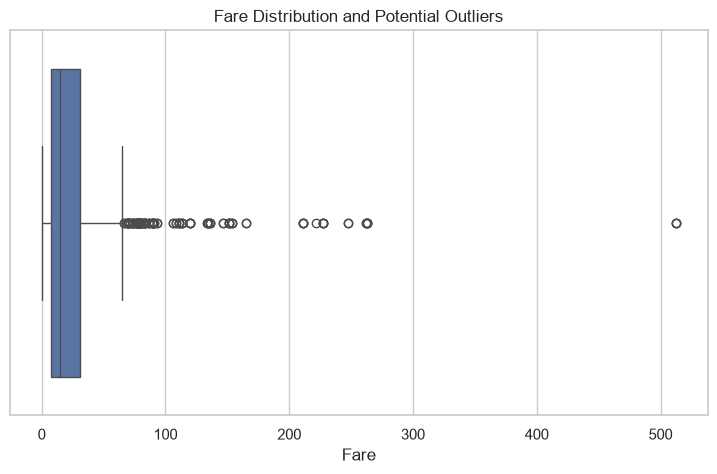

In [8]:
plt.figure(figsize=(9, 5))
sns.boxplot(x=clean_df['Fare'])
plt.title('Fare Distribution and Potential Outliers')
plt.xlabel('Fare')
plt.show()

## 9. Survival Distribution

A count plot shows how many passengers survived compared with those who did not.

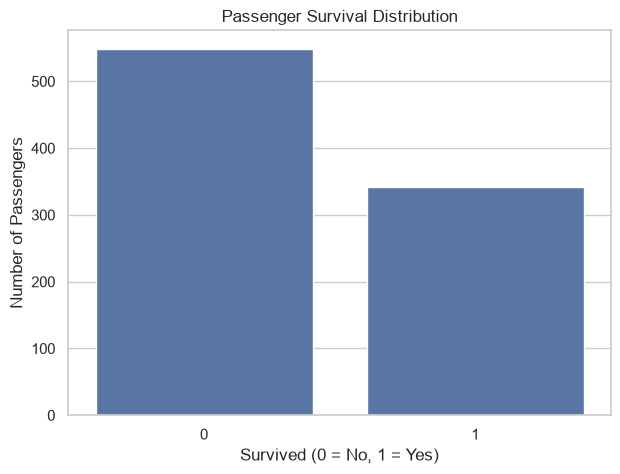

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=clean_df, x='Survived')
plt.title('Passenger Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

## 10. Survival by Gender

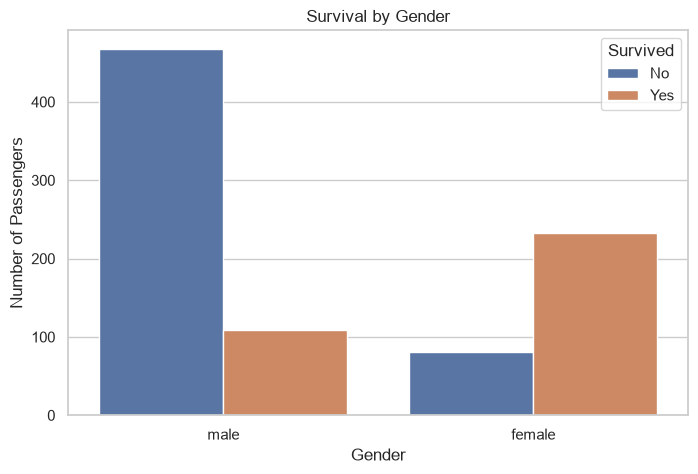

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## 11. Survival by Passenger Class

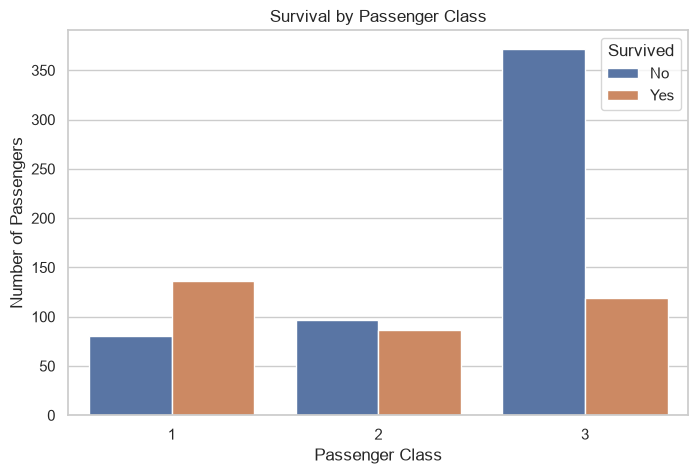

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=clean_df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## 12. Age Distribution

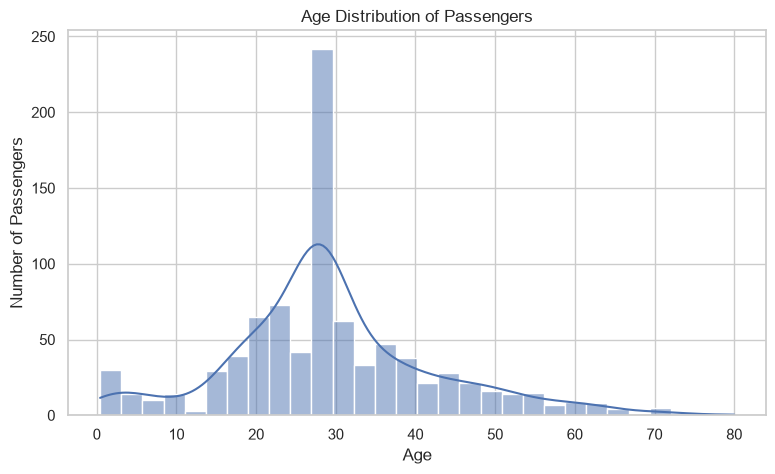

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(data=clean_df, x='Age', bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## 13. Fare Distribution by Passenger Class

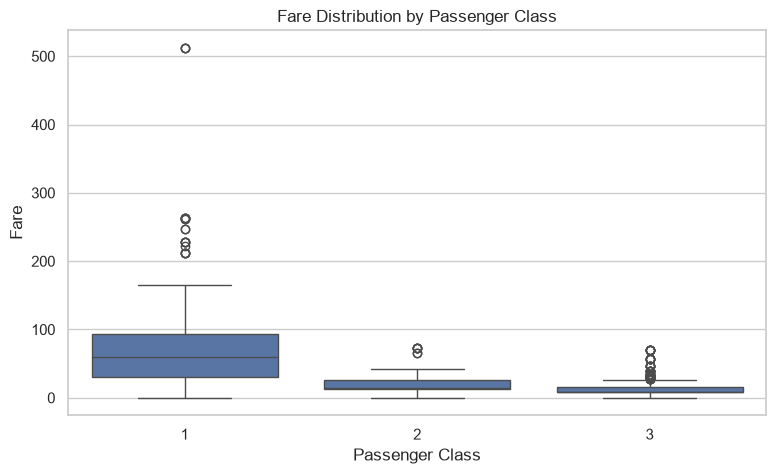

In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=clean_df, x='Pclass', y='Fare')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

## 14. Correlation Analysis

Correlation helps identify linear relationships between numerical variables.

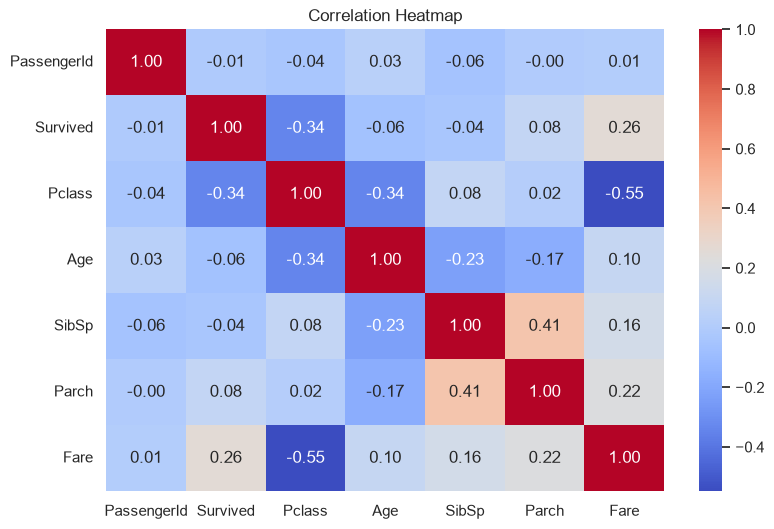

In [14]:
numeric_cols = clean_df.select_dtypes(include=np.number)

plt.figure(figsize=(9, 6))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 15. Key Findings

- The raw dataset contains missing values, especially in the `Age` and `Cabin` columns.
- Missing ages were handled using the median, while missing embarkation values were filled with the mode.
- The `Cabin` column was removed because a large proportion of its values were missing.
- Duplicate records were checked and removed where present.
- The `Fare` distribution contains potential high-value outliers based on the IQR method.
- Survival rates differ noticeably by gender and passenger class.
- Passenger class and fare show a relationship, with higher classes generally having higher fares.

## 16. Conclusion

This project demonstrated a complete basic data-cleaning and visualization workflow. The Titanic dataset was inspected, missing values were handled, duplicates were checked, potential outliers were identified, and several visualizations were created. The analysis shows how data preprocessing improves data quality and how visual storytelling can reveal meaningful patterns in a dataset.